In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from ase.visualize import view

In [ ]:
data = np.loadtxt("graphene_distance_scan.out")
copy = data.copy()

: 

In [ ]:
traj = read("relaxed_scan.lammpstrj", index = ":")

: 

In [ ]:
traj[-1].positions[2:]

array([[2.69081e-08, 1.41995e+00, 6.99967e+00],
       [1.22971e+00, 7.09975e-01, 6.99967e+00]])

: 

In [2]:
view(traj[55:], viewer = "ngl")

NameError: name 'traj' is not defined

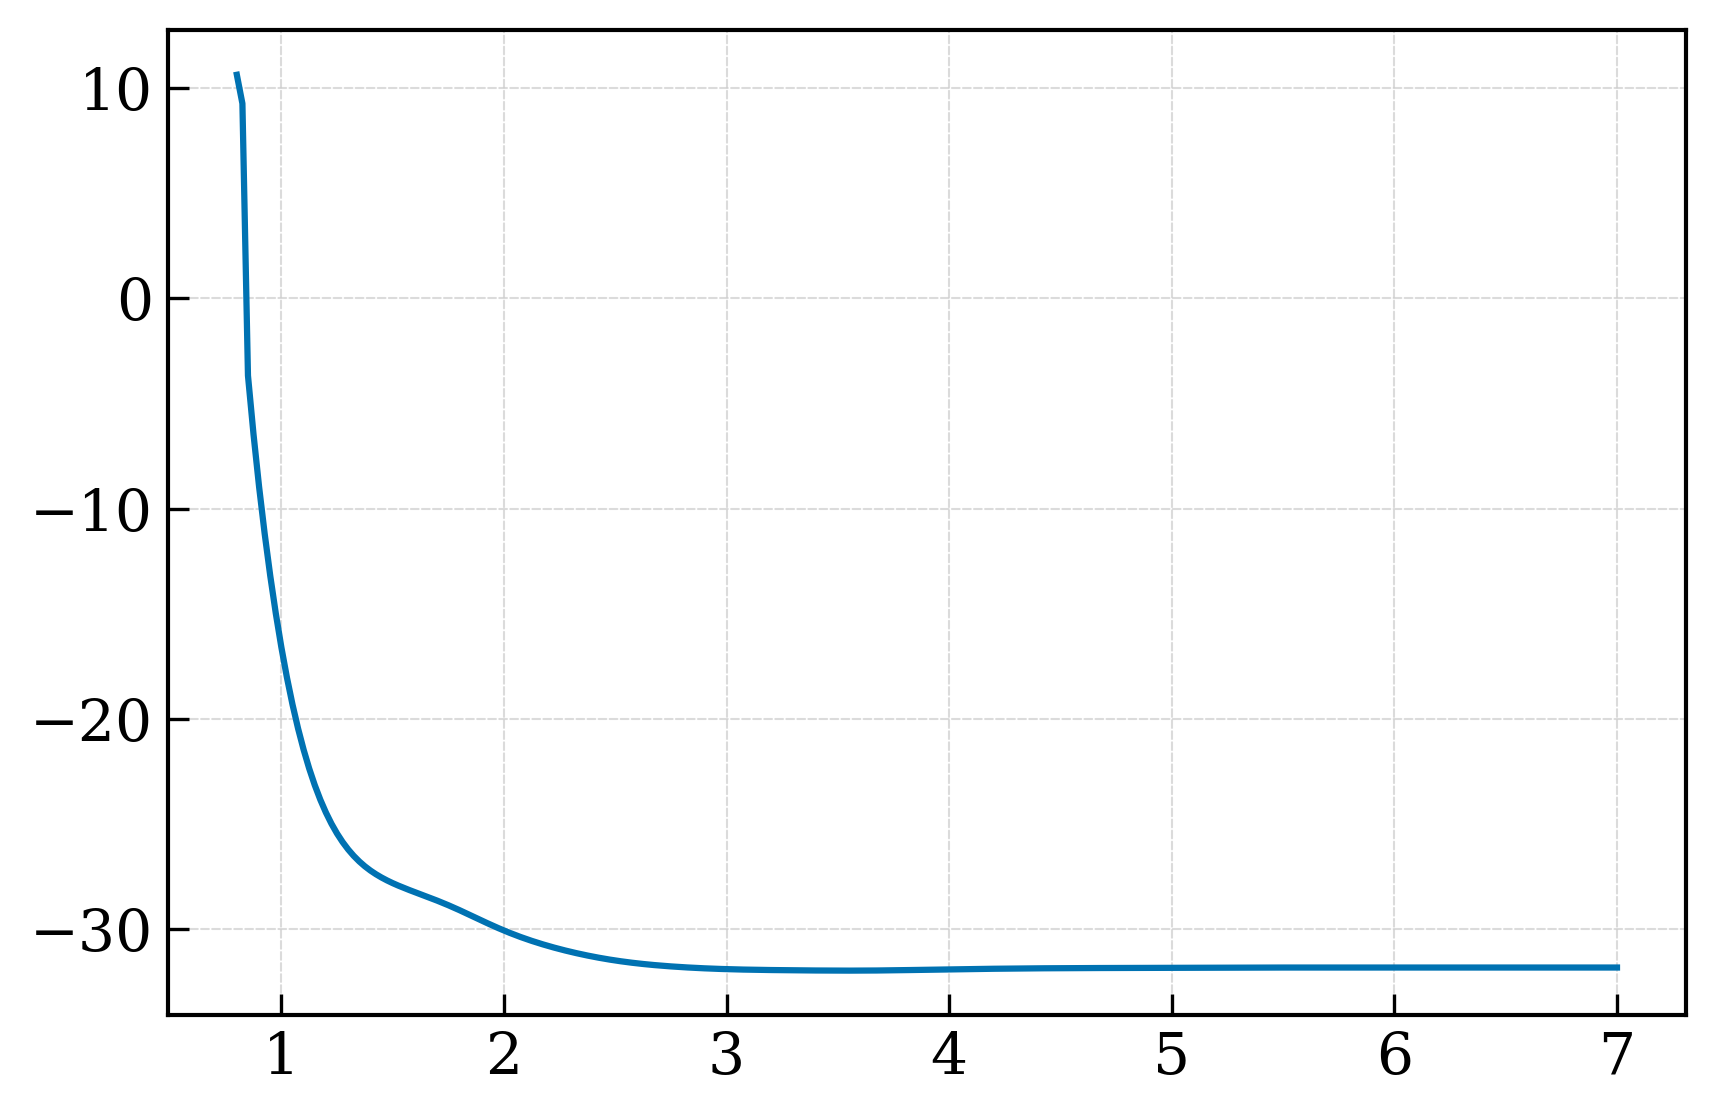

: 

In [ ]:
plt.plot(data[:,0], data[:,1])

In [ ]:
data[55,0]

np.float64(2.175)

: 

In [3]:
layer_center_distances = []
l1s = []
l0s = []

for a in traj:
    pos = a.positions
    l0 = np.sum(pos[:2,2])/2
    l1 = np.sum(pos[2:,2])/2
    l0s.append(l0)
    l1s.append(l1)
    layer_center_distances.append(l1 - l0)

copy[:,0] = layer_center_distances

NameError: name 'traj' is not defined

<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\A'
<>:164: SyntaxWarning: invalid escape sequence '\A'
<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\A'
<>:164: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_33114/1429730499.py:104: SyntaxWarning: invalid escape sequence '\p'
  label=f"Experimental: {experimental:.2f} $\pm$ {experimental_uncertainty:.2f} $\AA$",
/tmp/ipykernel_33114/1429730499.py:104: SyntaxWarning: invalid escape sequence '\A'
  label=f"Experimental: {experimental:.2f} $\pm$ {experimental_uncertainty:.2f} $\AA$",
/tmp/ipykernel_33114/1429730499.py:164: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel("Interlayer distance [$\AA$]")


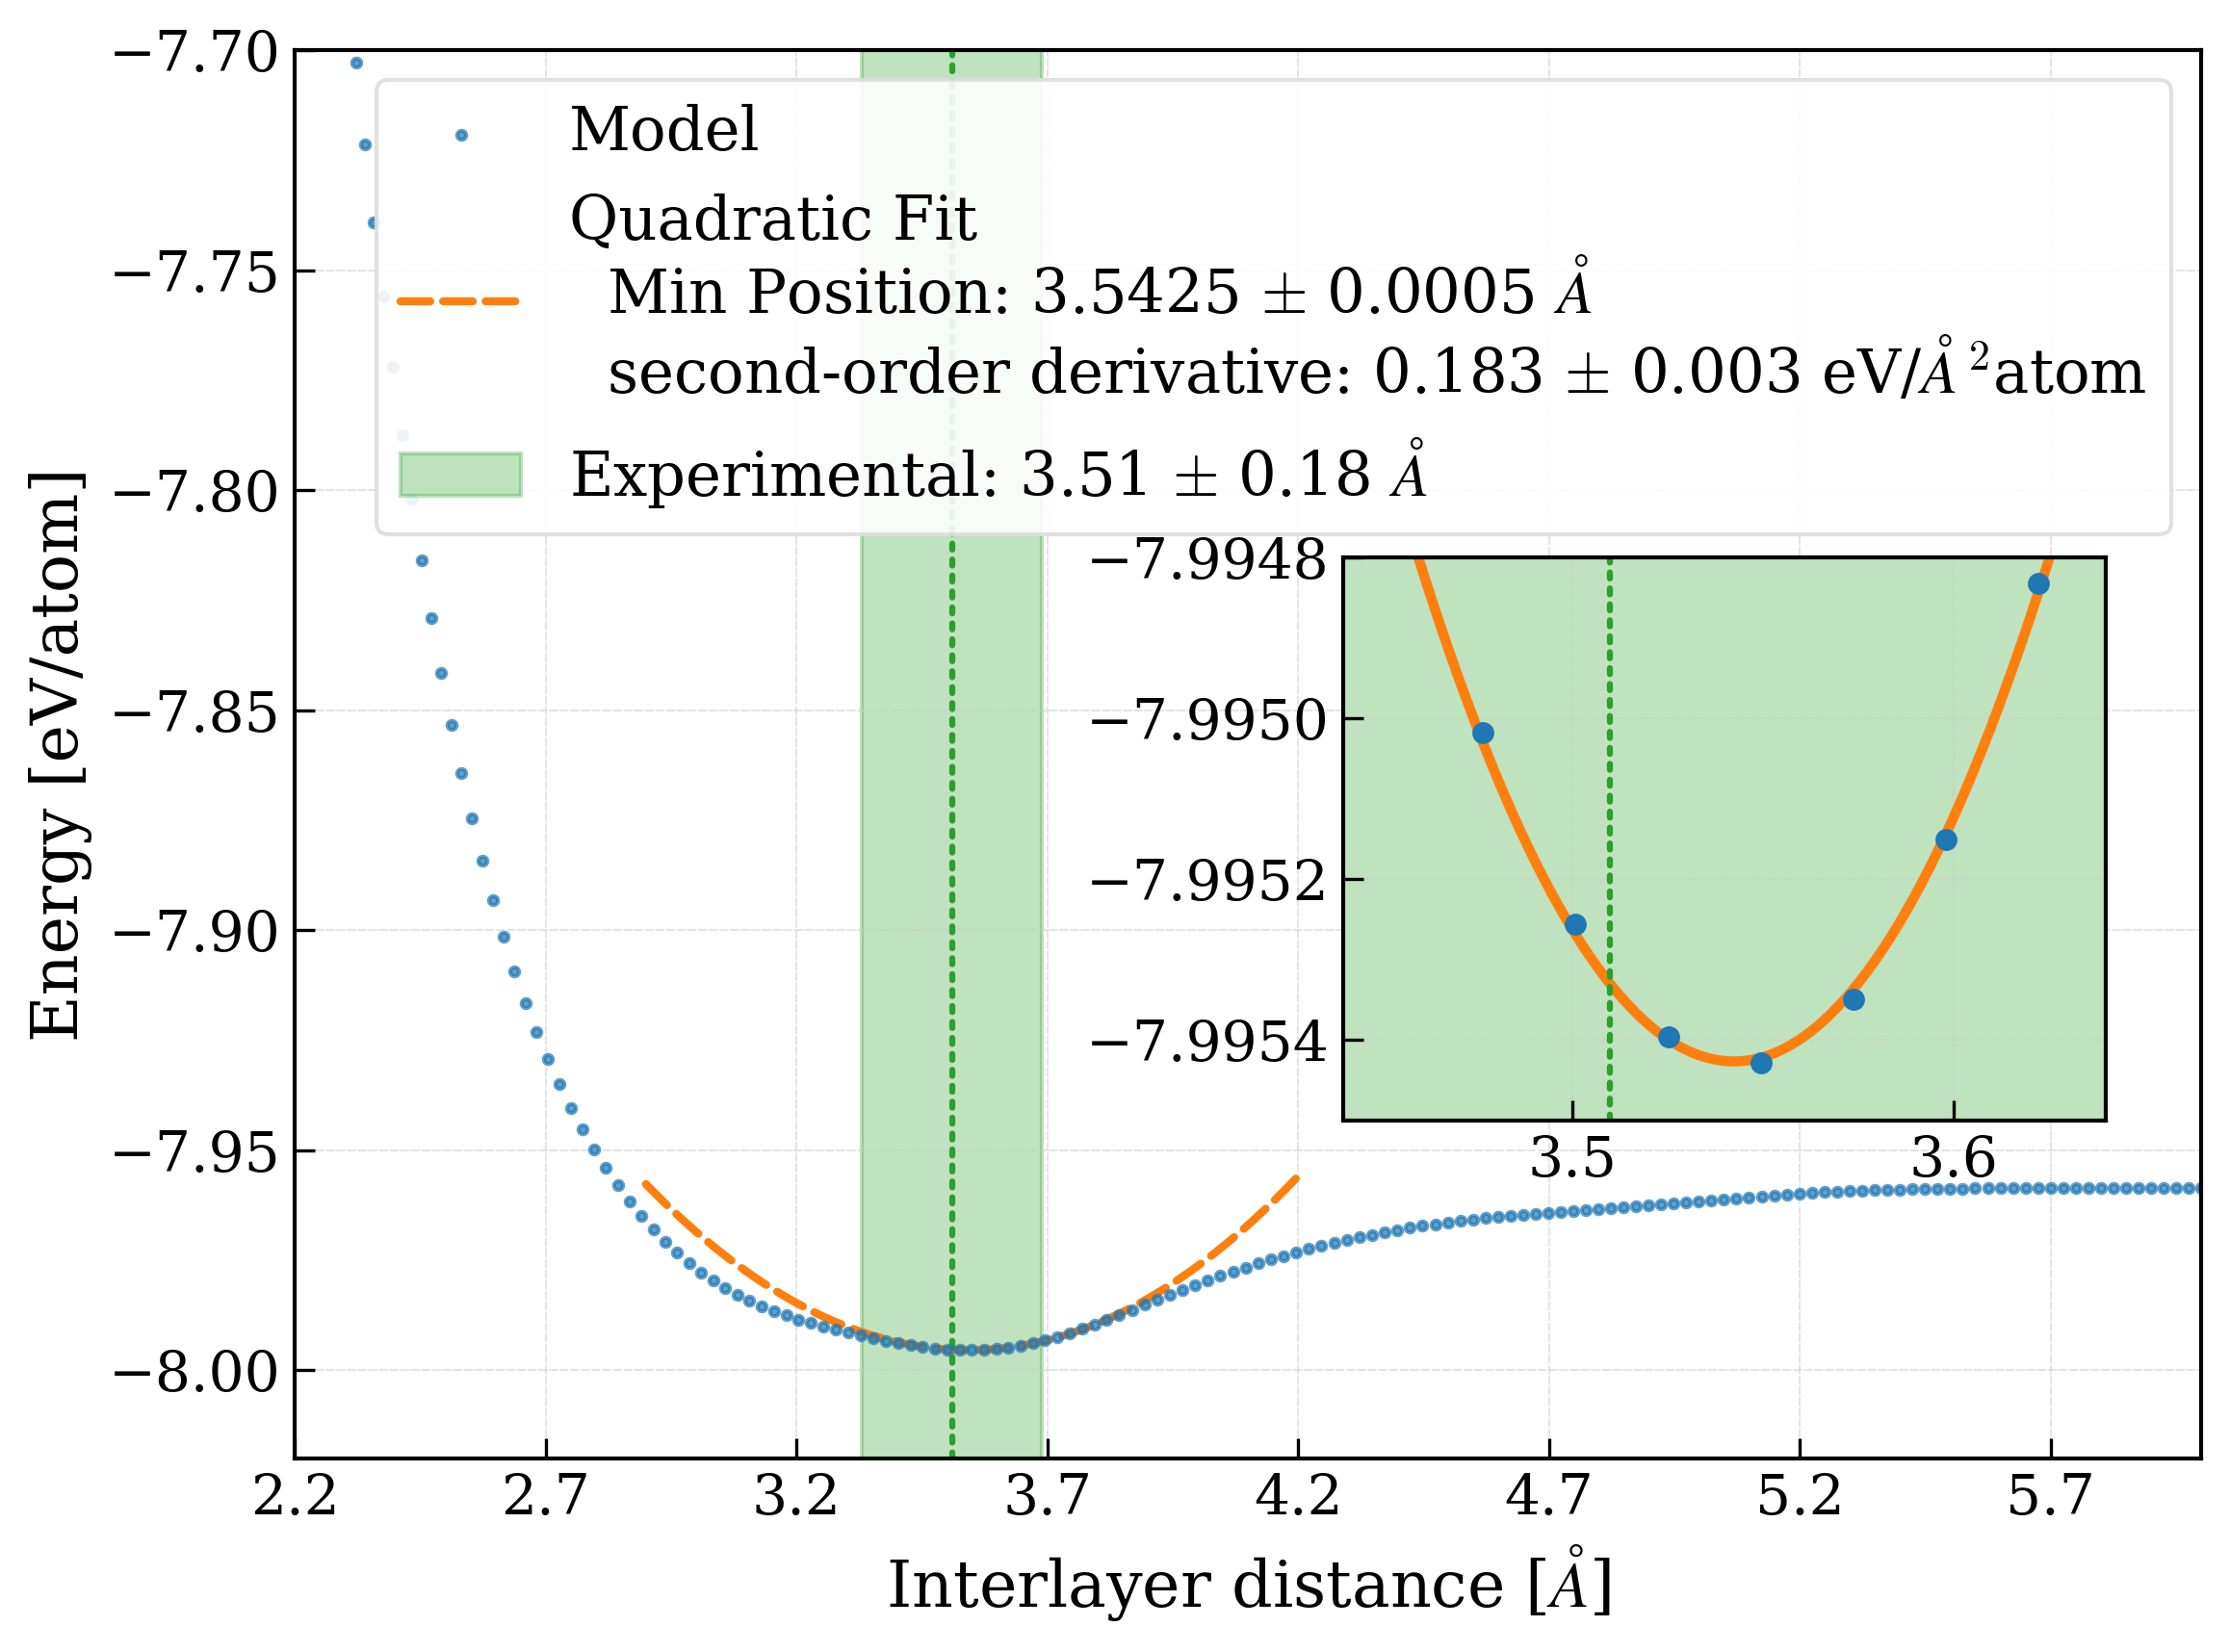

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import polyfit, poly1d

experimental = 3.51
experimental_uncertainty = 0.18

# Dummy data placeholder — replace with your actual 'data' matrix
# data = np.random.rand(1000, 2) 

# ==========================================
# 1. SETUP & INITIALIZATION
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))
scale = 1

# Scale the raw data axes directly for plotting consistency
x_scaled = data[:, 0] * scale
y_scaled = data[:, 1] / 4.0

# FIX: Added rasterized=True to fix the PDF rendering bug, 
# changed edgecolors to 'face', and set zorder=2 to place it on top.
ax.scatter(
    x_scaled, y_scaled, 
    label="Model", 
    color="#1f77b4", 
    alpha=0.7, 
    edgecolors='face', 
    s=5, 
    zorder=2,
    rasterized=True
)

# ==========================================
# 2. DATA FILTERING & POLYNOMIAL FITTING
# ==========================================
# Clean Inset Limits (defined in scaled units)
quadratic_limits = (3.44, 3.64)

# Masking using the scaled X values to target the zoom window
mask = (x_scaled > quadratic_limits[0]) & (x_scaled < quadratic_limits[1])
row_indices = np.where(mask)[0]

x_fit_pts = x_scaled[row_indices]
y_fit_pts = y_scaled[row_indices]

# Fit 2nd-degree polynomial to the scaled data window
# coeffs order: [a, b, c] for ax^2 + bx + c
coeffs, covar = polyfit(x_fit_pts, y_fit_pts, deg=2, cov=True)
poly2 = poly1d(coeffs)

# ==========================================
# 3. DERIVATIVE & MINIMUM CALCULATIONS WITH UNCERTAINTIES
# ==========================================
a, b, c = coeffs

# Extract variances and covariance from the fit matrix
# Indexing maps to [a, b, c]
var_a = covar[0, 0]
var_b = covar[1, 1]
cov_ab = covar[0, 1]

# 1. Minimum Position x_min = -b / (2a)
x_min = -b / (2 * a)
y_min = poly2(x_min)

# Error propagation for x_min: f(a,b) = -b / (2a)
# partial_a = b / (2 * a^2), partial_b = -1 / (2 * a)
df_da = b / (2 * (a ** 2))
df_db = -1 / (2 * a)
x_min_err = np.sqrt((df_da ** 2) * var_a + (df_db ** 2) * var_b + 2 * df_da * df_db * cov_ab)

# 2. Second-order derivative d^2E/dx^2 = 2a
d2E_dx2_scaled = 2 * a  
d2E_dx2_scaled_err = 2 * np.sqrt(var_a) # linear scaling of standard deviation

# 3. Rescaled back relative to the original unscaled data matrix axis
d2E_dx2_raw = d2E_dx2_scaled * (scale ** 2)

# ==========================================
# 4. MAIN PLOT ADDITIONS
# ==========================================
# Generate a wider X range for the main plot parabola
x_wide = np.linspace(2.9, 4.2, 200)

fit_label = (
    f"Quadratic Fit\n"
    rf"  Min Position: {x_min:.4f} $\pm$ {x_min_err:.4f} $\AA$"
    "\n"
    rf"  second-order derivative: {d2E_dx2_scaled:.3f} $\pm$ {d2E_dx2_scaled_err:.3f} eV/$\AA^2$atom"
)
# FIX: Set zorder=1 so the line passes underneath the data points
ax.plot(x_wide, poly2(x_wide), color="#ff7f0e", linestyle="--", linewidth=2, label=fit_label, zorder=1)

# --- EXPERIMENTAL VALUE & UNCERTAINTY (MAIN PLOT) ---
exp_low = experimental - experimental_uncertainty
exp_high = experimental + experimental_uncertainty

# Shaded region for uncertainty window (zorder=0 pins it behind elements)
ax.axvspan(
    exp_low, exp_high, 
    color="#2ca02c", 
    alpha=0.3, 
    label=f"Experimental: {experimental:.2f} $\pm$ {experimental_uncertainty:.2f} $\AA$", 
    zorder=0
)
# Central vertical guideline
ax.axvline(experimental, color="#2ca02c", linestyle=":", linewidth=1.5, zorder=1)

# ==========================================
# 5. INSET SETUP & ZOOM
# ==========================================
axins = ax.inset_axes([0.55, 0.24, 0.4, 0.4]) 

# FIX: Added rasterized=True and zorder=2 to mirror the main axes fixes
axins.scatter(
    x_scaled, y_scaled, 
    color="#1f77b4", 
    s=20, 
    edgecolors='face',
    zorder=2,
    rasterized=True
)

# Plot the fitted parabola segment tightly inside the inset
x_ins_fit = np.linspace(quadratic_limits[0], quadratic_limits[1], 100)
# FIX: Set zorder=1 for the inset line
axins.plot(x_ins_fit, poly2(x_ins_fit), color="#ff7f0e", linewidth=2.5, zorder=1)

# --- EXPERIMENTAL VALUE & UNCERTAINTY (INSET) ---
# Check if the experimental range falls completely inside, completely outside, or overlaps the inset window
if exp_high >= quadratic_limits[0] and exp_low <= quadratic_limits[1]:
    # Visible overlapping region
    actual_low = max(exp_low, quadratic_limits[0])
    actual_high = min(exp_high, quadratic_limits[1])
    axins.axvspan(actual_low, actual_high, color="#2ca02c", alpha=0.3, zorder=0)
    if quadratic_limits[0] <= experimental <= quadratic_limits[1]:
        axins.axvline(experimental, color="#2ca02c", linestyle=":", linewidth=1.5, zorder=1)
else:
    # Off-screen indicator logic
    y_mid_inset = ( -7.9955 + -7.9948 ) / 2.0
    if experimental > quadratic_limits[1]:
        axins.axvline(quadratic_limits[1], color="#2ca02c", linestyle="-.", alpha=0.5, zorder=1)
        axins.annotate("", xy=(quadratic_limits[1] - 0.005, y_mid_inset), xytext=(quadratic_limits[1] - 0.02, y_mid_inset),
                       arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.5))
        axins.text(quadratic_limits[1] - 0.007, y_mid_inset + 0.0001, "Exp. $\\rightarrow$", color="#2ca02c", fontsize=9, ha='right')
    elif experimental < quadratic_limits[0]:
        axins.axvline(quadratic_limits[0], color="#2ca02c", linestyle="-.", alpha=0.5, zorder=1)
        axins.annotate("", xy=(quadratic_limits[0] + 0.005, y_mid_inset), xytext=(quadratic_limits[0] + 0.02, y_mid_inset),
                       arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.5))
        axins.text(quadratic_limits[0] + 0.007, y_mid_inset + 0.0001, "$\\leftarrow$ Exp.", color="#2ca02c", fontsize=9, ha='left')

# Set tight bounds on the inset to look directly at the valley minimum
axins.set_xlim(quadratic_limits) 
axins.set_ylim(-7.9955, -7.9948)
axins.grid(True, linestyle=":", alpha=0.6)

# Draw the connector lines from the main plot box to the inset axes
# ax.indicate_inset_zoom(axins, edgecolor="gray", alpha=0.5)

# ==========================================
# 6. GLOBAL FORMATTING & EXPORT
# ==========================================
ax.set_xlabel("Interlayer distance [$\AA$]")
ax.set_ylabel("Energy [eV/atom]")
ax.set_ylim(-8.02, -7.7)
xmin, xmax = 2.2, 6
ax.set_xlim(xmin, xmax)
ax.set_xticks(np.arange(xmin, xmax, 0.5))

ax.legend(loc="upper right", framealpha=0.9, fontsize=15)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("BM_graphene_interlayer_distance.pdf", bbox_inches="tight")
plt.show()

(-0.01, 0.01)

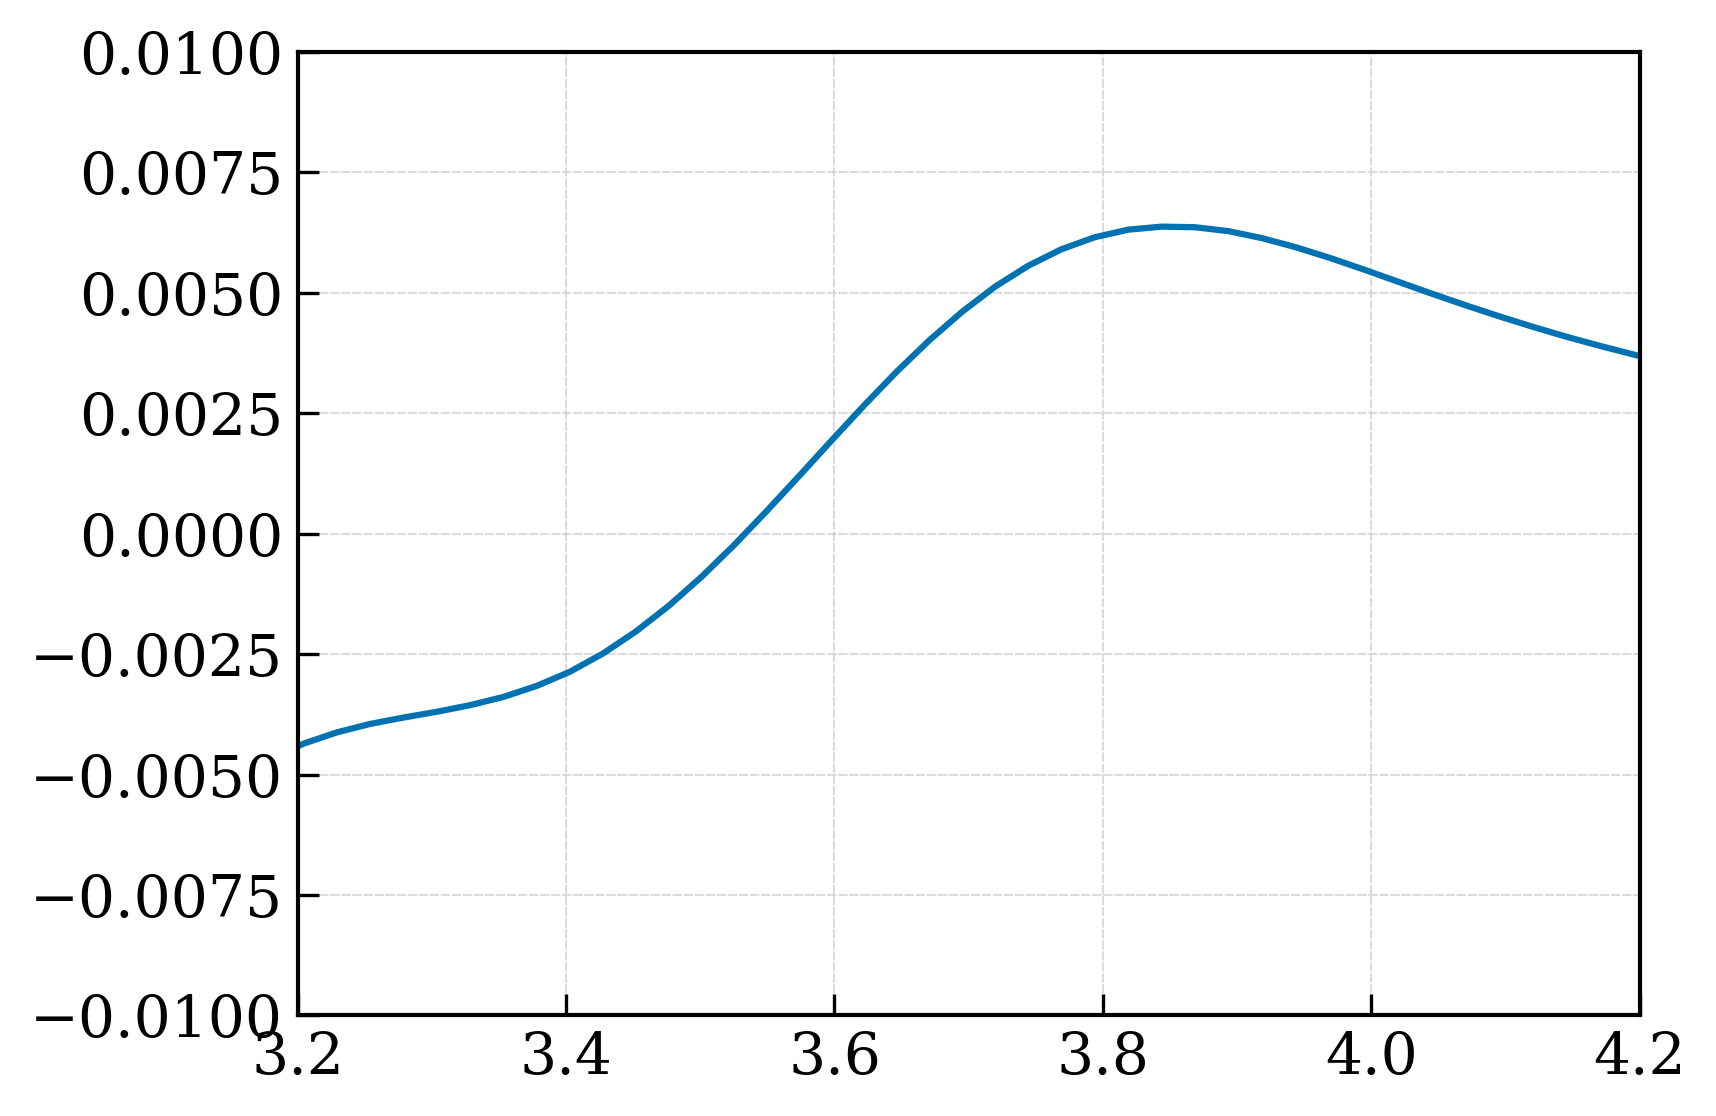

: 

In [ ]:
plt.plot(data[55:,0], copy[55:,0] - data[55:,0])
plt.xlim(3.2, 4.2)
plt.ylim(-1e-2, 1e-2)